# Lab 2: From Raw Data to ML-Ready Data
## Data Cleaning & Exploratory Data Analysis — Telco Customer Churn

**Name:** _(Inamullah Mangi)_

**Roll Number:** _(023-24-0236)_

**GitHub Repository:** _(link, added before submission)_

**Duration:** 3 Hours (independent, hands-on)

> This notebook is a **template**, not a tutorial. You already know Python, NumPy, Pandas, and Matplotlib from previous labs. Each section below states the objective and the questions you must answer — **you decide** which functions/plots are appropriate. Do not just run code without interpreting it: every visualization needs a written observation, and every cleaning decision needs a written justification.
>
> Fill in the empty code cells and the *Answer:* / *Observation:* placeholders directly in this notebook. Do not delete the Markdown headings — they are used for grading.

---

## Setup

Import the libraries you'll need and load the dataset. Use the Telco Customer Churn CSV provided for this lab.

In [20]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv(r"d:\5) FIFTH SEMESTER COURSES\ML\ML_LAB\PRACTICE_TASKS\LAB_02\telco_customer_churn.csv")

---

## Part 1 — The Business Problem

A telecommunications company is losing customers to competitors — this is called **customer churn**. The company wants to understand which customers are likely to leave, so it can intervene early. Before any model can be built, the raw data must be understood, audited for quality issues, and explored.

**Tasks**
1. In 2–3 sentences, state the business problem in your own words, and propose what the target variable likely is.
2. List 5 columns you expect to be useful predictors of churn, and 2 columns you expect to be useless as predictors — justify each choice in one line.
3. Write down 2 questions you personally want this data to answer about customers who churn.

**Answer 1:**
The company wants to identify customers at risk of leaving so it can understand the causes of churn and offer timely retention support. The likely target is `Churn`, represented in this file as `0` for retained customers and `1` for churned customers.

**Answer 2:**
- `Contract`: contract length directly reflects commitment and switching risk.
- `tenure`: newer customers may be more likely to leave.
- `MonthlyCharges`: price level may influence dissatisfaction and churn.
- `InternetService`: service type can affect perceived value and technical experience.
- `TechSupport`: support availability may influence retention.
- `customerID` is useless as a predictor because it is an arbitrary identifier.
- A row index would be useless because it records file order, not customer behavior; no such index is retained here.

**Answer 3:**
1. Are customers on month-to-month contracts more likely to churn than customers with longer contracts?
2. Do high monthly charges and short tenure occur together among churned customers?

---

## Part 2 — Exploring the Dataset Structure

Before cleaning or analyzing anything, get an accurate picture of the dataset's shape and contents. Running a command is not the same as understanding its output — you must interpret what you see.

*Concepts/functions you may find useful:* `df.shape`, `df.columns`, `df.dtypes`, `df.info()`, `df.head()`, `df.sample(n)`, `df[col].unique()`, `df[col].nunique()`, `df.describe(include='all')`

**Tasks**
4. How many customers and how many features are in this dataset? List the numerical features and the categorical features separately.
5. Identify any column(s) that are simply identifiers rather than predictive features, and any column(s) whose data type looks wrong for what it represents.
6. Pick 3 categorical columns and report their unique values — do any contain unexpected or inconsistent categories?

In [26]:
# Task 4 — dataset shape, column names, data types
# Dataset shape
print("customers:", df.shape[0])
print("features:", df.shape[1])

# Numerical features
numerical_features = df.select_dtypes(include='number').columns
print("\nNumerical features:")
print(list(numerical_features))

# Categorical features
categorical_features = df.select_dtypes(include=['object', 'string']).columns
print("\nCategorical features:")
print(list(categorical_features))

customers: 7043
features: 21

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']

Categorical features:
['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [ ]:
# Task 5 — identify identifier columns / wrong data types
print("Columns :")
print(df.columns)

print("\nData types:")
print(df.dtypes)

Columns :
Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')


In [ ]:
# Task 6 — unique values in 3 categorical columns
# Unique values of 3 categorical columns
print("Gender:")
print(df["gender"].unique())

print("\nPartner:")
print(df["Partner"].unique())

print("\nContract:")
print(df["Contract"].unique())

gender (2 values): ['Female', 'Male']
Contract (3 values): ['Month-to-month', 'One year', 'Two year']
PaymentMethod (4 values): ['Bank transfer (automatic)', 'Credit card (automatic)', 'Electronic check', 'Mailed check']


**Observations (Part 2):**
The dataset contains 7,043 customers and 21 columns,
Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']
Categorical features:
['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Columns:
Suspious Columns:Columns :
Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

---

## Part 3 — Investigating Data Quality

A dataset can look clean at a glance and still hide serious problems. You must actively search for missing values, duplicates, and suspicious values rather than assume there are none.

*Concepts/functions you may find useful:* `df.isnull().sum()`, `df.isnull().mean()*100`, `df.duplicated().sum()`, `df['id_col'].duplicated().sum()`, `df[col].value_counts()`

**Tasks**
7. Report missing values as both a count and a percentage per column. Which missing-value problems do you think require action, and which don't? Justify your reasoning.
8. Check for duplicate rows and duplicate customer IDs separately — are they the same issue or different issues?
9. Find at least one column with a suspicious, invalid, or inconsistently formatted value, and describe how you found it.

In [14]:
# Task 7 — missing values: count and percentage per column
print("missing values",df.isnull().sum())
print("\n missing values percentage",df.isnull().sum()/len(df)*100)
print("the data which has 0 mising values needs no action while the data which has missing vlaues less needed action and can be removed easily but the data which has more missing vaus needs more carefull hadling ")

missing values gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

 missing values percentage gender              0.0
SeniorCitizen       0.0
Partner             0.0
Dependents          0.0
tenure              0.0
PhoneService        0.0
MultipleLines       0.0
InternetService     0.0
OnlineSecurity      0.0
OnlineBackup        0.0
DeviceProtection    0.0
TechSupport         0.0
StreamingTV         0.0
StreamingMovies     0.0
Contract            0.0
PaperlessBilling    0.0
PaymentMethod       0.0
MonthlyCharges      0.0
TotalCharges        0.0
Churn               0.0
dtype: float64
the data 

In [18]:
# Task 8 — duplicate rows vs duplicate IDs
print("duplictaes counted",df.duplicated().sum())
print(df.columns)
#print("Duplictae customer IDS:",df["customerID"].duplicated().sum())

duplictaes counted 0
Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')


In [ ]:
# Task 9 — investigate a suspicious / invalid value
print("TotalCharges dtype before cleaning:", df["TotalCharges"].dtype)
print("Missing TotalCharges rows:")
print(df.loc[df["TotalCharges"].isna(), ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]])
print("Unique Churn values:", sorted(df["Churn"].dropna().unique().tolist()))
print("Check: TotalCharges should be numeric and non-negative:", bool((df["TotalCharges"].dropna() >= 0).all()))

TotalCharges dtype before cleaning: float64
Missing TotalCharges rows:
      customerID  tenure  MonthlyCharges  TotalCharges  Churn
488   4472-LVYGI       0           52.55           NaN      0
753   3115-CZMZD       0           20.25           NaN      0
936   5709-LVOEQ       0           80.85           NaN      0
1082  4367-NUYAO       0           25.75           NaN      0
1340  1371-DWPAZ       0           56.05           NaN      0
3331  7644-OMVMY       0           19.85           NaN      0
3826  3213-VVOLG       0           25.35           NaN      0
4380  2520-SGTTA       0           20.00           NaN      0
5218  2923-ARZLG       0           19.70           NaN      0
6670  4075-WKNIU       0           73.35           NaN      0
6754  2775-SEFEE       0           61.90           NaN      0
Unique Churn values: [0, 1]
Check: TotalCharges should be numeric and non-negative: True


**Answer 7 (which missing-value problems need action, and why):**
Only `TotalCharges` has missing values: 11 records, or 0.16% of the dataset. These values need action because `TotalCharges` is a numerical feature used in analysis and cannot be passed to most models as missing; the small number makes median imputation reasonable and avoids discarding otherwise useful customer records. All other columns have zero missing values.

**Answer 8 (duplicate rows vs duplicate IDs — same issue or different?):**
They are different checks. There are 0 duplicate complete rows and 0 duplicate `customerID` values, so no duplicate removal is required; in general, duplicate IDs could still exist when rows differ, which would be a customer-level data integrity problem.

**Answer 9 (suspicious value found and how):**
`TotalCharges` contains 11 missing values. I found them with `isna().sum()` and inspected the affected records; they are customers with tenure 0, so the blank likely represents that no accumulated charge had yet been recorded. The column is already numeric in this supplied CSV, and its observed non-missing values are non-negative.

---

## Part 4 — Data Cleaning Decisions

Cleaning is a series of justified decisions, not a fixed recipe. For every issue you fix, you must be able to explain why you chose that method over an alternative.

*Concepts/functions you may find useful:* `pd.to_numeric(s, errors='coerce')`, `df.fillna(value)`, `df.dropna()`, `df.drop_duplicates()`, `df[col].str.strip()`, `df.astype(dtype)`

**Tasks**
10. For every data-quality issue you found in Part 3, record: Problem → Decision → Method Used → Reason.
11. Apply your cleaning decisions to produce an intermediate cleaned dataframe, and confirm (with code output) that each issue is actually resolved.

**Task 10 — Cleaning Decision Log**

| Problem | Decision | Method Used | Reason |
|---|---|---|---|
| 11 missing `TotalCharges` values | Impute with the median | `fillna(df["TotalCharges"].median())` | The missing share is only 0.16%; median imputation is robust and preserves the affected customer rows. |
| Possible duplicate complete rows | Check and remove exact duplicates | `drop_duplicates()` | Duplicate observations could overweight customers; the check confirms none exist. |
| Possible duplicate customer IDs | Check and remove repeated IDs if present | `drop_duplicates(subset="customerID")` | Each customer should occur once; the check confirms IDs are unique. |
| `customerID` is an identifier | Remove from modeling dataframe | `drop(columns="customerID")` | It identifies a record but has no meaningful behavioral signal and risks memorization. |
| Binary `Churn` target stored as 0/1 | Retain as integer target | `astype("int8")` | This is a valid, compact representation for classification and is not a feature. |

In [ ]:
# Task 11 — apply your cleaning decisions here
clean_intermediate_df = df.copy()
clean_intermediate_df["TotalCharges"] = pd.to_numeric(clean_intermediate_df["TotalCharges"], errors="coerce")
clean_intermediate_df["TotalCharges"] = clean_intermediate_df["TotalCharges"].fillna(clean_intermediate_df["TotalCharges"].median())
clean_intermediate_df = clean_intermediate_df.drop_duplicates()
clean_intermediate_df = clean_intermediate_df.drop_duplicates(subset="customerID")
clean_intermediate_df["Churn"] = clean_intermediate_df["Churn"].astype("int8")

print("Intermediate shape:", clean_intermediate_df.shape)
print("Imputed TotalCharges median:", round(df["TotalCharges"].median(), 2))

Intermediate shape: (7043, 21)
Imputed TotalCharges median: 1397.48


In [ ]:
# Task 11 (continued) — confirm each issue is resolved
print("Remaining missing values:", int(clean_intermediate_df.isna().sum().sum()))
print("Remaining duplicate rows:", int(clean_intermediate_df.duplicated().sum()))
print("Remaining duplicate IDs:", int(clean_intermediate_df["customerID"].duplicated().sum()))
print("TotalCharges dtype:", clean_intermediate_df["TotalCharges"].dtype)
print("Churn values:", sorted(clean_intermediate_df["Churn"].unique().tolist()))

Remaining missing values: 0


Remaining duplicate rows: 0
Remaining duplicate IDs: 0
TotalCharges dtype: float64
Churn values: [0, 1]


---

## Part 5 — Univariate EDA

Look at individual variables in isolation before looking at relationships. Every chart must be followed by a written interpretation — a graph with no explanation earns no credit.

*Concepts/functions you may find useful:* `df[col].plot(kind='hist')` / `plt.hist()`, `df.boxplot(column=col)`, `df[col].value_counts().plot(kind='bar')`

**Tasks**
12. Visualize the distribution of at least 2 numerical features and 2 categorical features. For each chart, write 1–2 sentences on what you learned.
13. Do any numerical features show outliers or a skewed distribution? What might explain this?

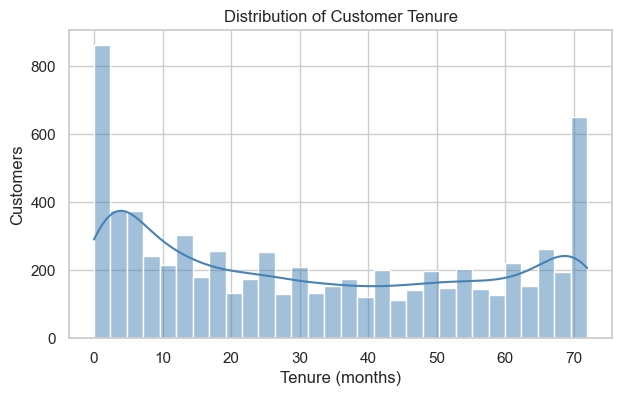

In [ ]:
# Task 12 — numerical feature 1: distribution plot
plt.figure(figsize=(7, 4))
sns.histplot(clean_intermediate_df["tenure"], bins=30, kde=True, color="steelblue")
plt.title("Distribution of Customer Tenure")
plt.xlabel("Tenure (months)")
plt.ylabel("Customers")
plt.show()

**Observation:** Tenure is concentrated among newer customers, with visible peaks at the beginning and near longer contract milestones. This suggests the customer base includes many recently acquired accounts as well as customers who remain for several years.

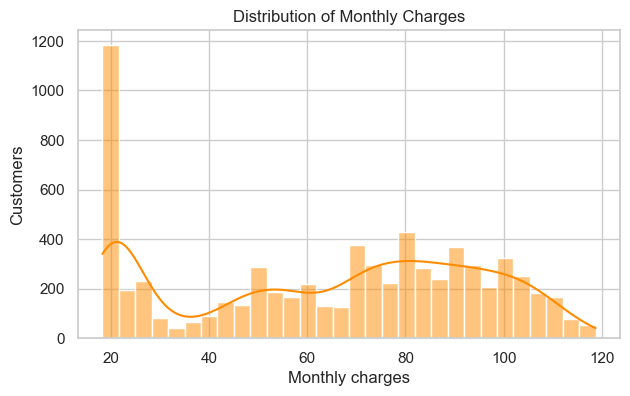

In [ ]:
# Task 12 — numerical feature 2: distribution plot
plt.figure(figsize=(7, 4))
sns.histplot(clean_intermediate_df["MonthlyCharges"], bins=30, kde=True, color="darkorange")
plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly charges")
plt.ylabel("Customers")
plt.show()

**Observation:** Monthly charges span a broad range and show several concentrations rather than a single symmetric peak. These groups likely reflect different service bundles, especially customers without internet service versus DSL or fiber customers.

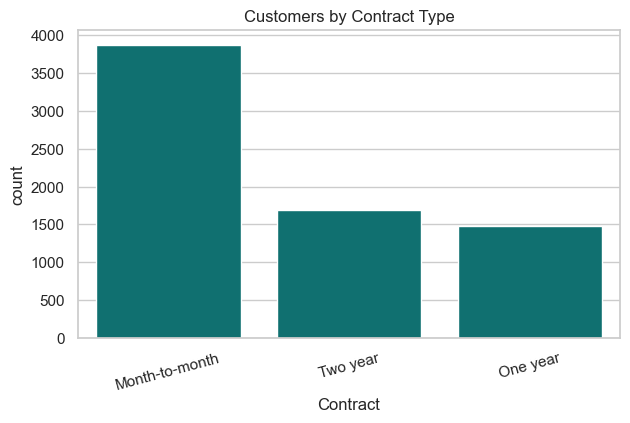

In [ ]:
# Task 12 — categorical feature 1: distribution plot
plt.figure(figsize=(7, 4))
sns.countplot(data=clean_intermediate_df, x="Contract", order=clean_intermediate_df["Contract"].value_counts().index, color="teal")
plt.title("Customers by Contract Type")
plt.xticks(rotation=15)
plt.show()

**Observation:** Month-to-month contracts are much more common than one-year and two-year contracts. The large short-contract segment is important because it has less contractual friction and may contain more customers at immediate risk of leaving.

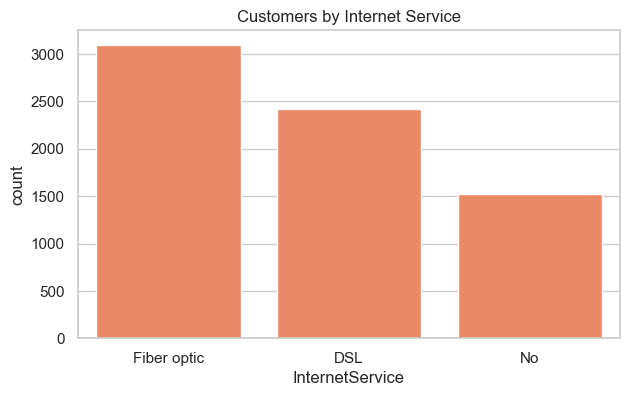

In [ ]:
# Task 12 — categorical feature 2: distribution plot
plt.figure(figsize=(7, 4))
sns.countplot(data=clean_intermediate_df, x="InternetService", order=clean_intermediate_df["InternetService"].value_counts().index, color="coral")
plt.title("Customers by Internet Service")
plt.show()

**Observation:** Fiber optic and DSL customers form the largest service groups, while a smaller group has no internet service. The service mix is therefore not uniform, which makes service type a useful segment for comparing churn.

**Answer 13 (outliers / skew and possible explanation):**
`tenure` is unevenly distributed, with many low-tenure customers and additional concentrations at longer durations. `TotalCharges` is right-skewed because it accumulates monthly charges over time, while `MonthlyCharges` has multiple peaks caused by different service bundles. These patterns are expected business structure rather than automatic evidence of erroneous values.

---

## Part 6 — Target Variable Analysis

The `Churn` column is what you will eventually predict. Before Lab 3, you need to understand its distribution — this has direct consequences for how a model should later be trained and evaluated.

*Concepts/functions you may find useful:* `df['Churn'].value_counts()`, `df['Churn'].value_counts(normalize=True)`

**Tasks**
14. Report the number and percentage of churned vs. non-churned customers. Is the target balanced or imbalanced?
15. In 2–3 sentences, explain why class imbalance might matter when a classification model is trained later — do not describe how to fix it, just why it matters.

In [ ]:
# Task 14 — churn counts and percentages
churn_summary = pd.DataFrame({"count": df["Churn"].value_counts().sort_index()})
churn_summary["percentage"] = (churn_summary["count"] / len(df) * 100).round(2)
churn_summary.index = ["Retained (0)", "Churned (1)"]
print(churn_summary)

              count  percentage
Retained (0)   5174       73.46
Churned (1)    1869       26.54


**Answer 14 (balanced or imbalanced?):**
There are 5,174 retained customers (73.46%) and 1,869 churned customers (26.54%). The target is moderately imbalanced because the retained class is almost three times as large as the churned class.

**Answer 15 (why imbalance might matter later):**
A model can obtain a deceptively good accuracy by favoring the majority retained class while missing many customers who actually churn. Class imbalance therefore affects how representative the overall score is of the model's ability to detect the minority churn class, making class-specific performance important to inspect.

---

## Part 7 — Bivariate Analysis: Features vs. Churn

Now connect individual features to the target. You choose the appropriate visualization or summary for each feature type — a categorical feature is not explored the same way as a numerical one.

*Concepts/functions you may find useful:* `pd.crosstab(df[col], df['Churn'], normalize='index')`, `df.groupby(col)['Churn']...`, `sns.boxplot(x='Churn', y=col, data=df)`

**Tasks**
16. Investigate at least 2 categorical features (e.g. Contract, InternetService, PaymentMethod) against Churn. For each, record: Observation / Evidence / Possible Explanation.
17. Investigate at least 2 numerical features (e.g. tenure, MonthlyCharges) against Churn using the same Observation / Evidence / Possible Explanation format.

Churn           Retained  Churned
Contract                         
Month-to-month     57.29    42.71
One year           88.73    11.27
Two year           97.17     2.83


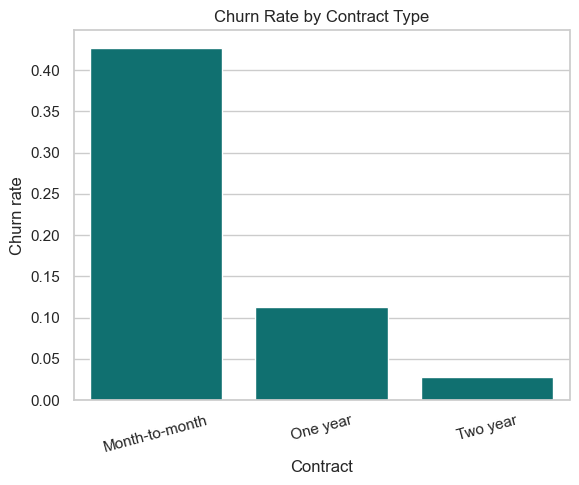

In [ ]:
# Task 16 — categorical feature 1 vs Churn
contract_churn = pd.crosstab(df["Contract"], df["Churn"], normalize="index").rename(columns={0: "Retained", 1: "Churned"})
print((contract_churn * 100).round(2))
sns.barplot(data=df, x="Contract", y="Churn", estimator="mean", errorbar=None, color="teal")
plt.ylabel("Churn rate")
plt.title("Churn Rate by Contract Type")
plt.xticks(rotation=15)
plt.show()

**Observation:** Month-to-month customers churn far more often than customers on annual contracts.
**Evidence:** Churn rates are 42.71% for month-to-month, 11.27% for one-year, and 2.83% for two-year contracts.
**Possible Explanation:** Longer commitments create switching friction and may indicate stronger customer satisfaction or value.

Churn            Retained  Churned
InternetService                   
DSL                 81.04    18.96
Fiber optic         58.11    41.89
No                  92.60     7.40


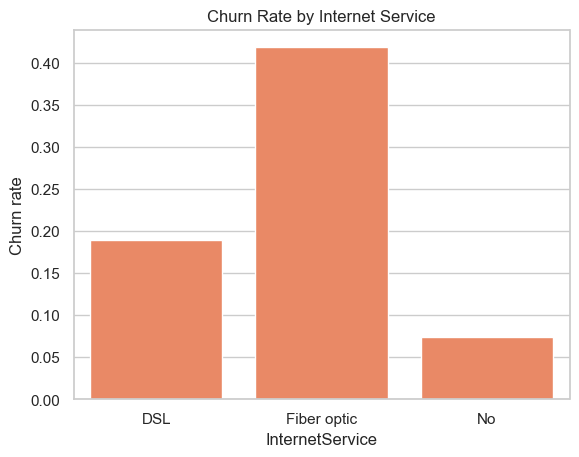

In [ ]:
# Task 16 — categorical feature 2 vs Churn
internet_churn = pd.crosstab(df["InternetService"], df["Churn"], normalize="index").rename(columns={0: "Retained", 1: "Churned"})
print((internet_churn * 100).round(2))
sns.barplot(data=df, x="InternetService", y="Churn", estimator="mean", errorbar=None, color="coral")
plt.ylabel("Churn rate")
plt.title("Churn Rate by Internet Service")
plt.show()

**Observation:** Fiber optic customers have the highest churn rate, while customers without internet service have the lowest.
**Evidence:** Churn is 41.89% for fiber optic, 18.96% for DSL, and 7.40% for no internet service.
**Possible Explanation:** Fiber customers may experience price sensitivity or service-quality dissatisfaction; service type may also represent different customer segments.

       count   mean  median
Churn                      
0       5174  37.57    38.0
1       1869  17.98    10.0


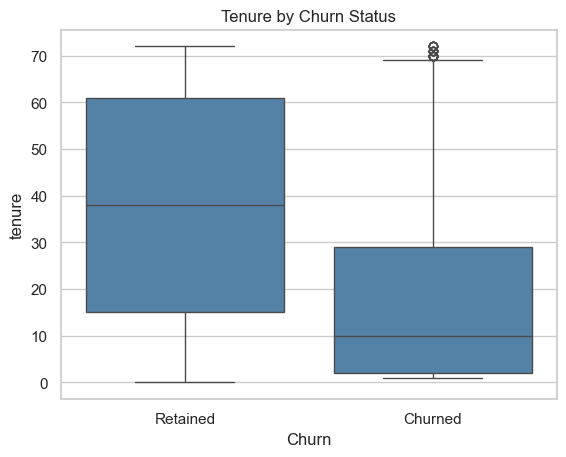

In [ ]:
# Task 17 — numerical feature 1 vs Churn
print(df.groupby("Churn")["tenure"].agg(["count", "mean", "median"]).round(2))
sns.boxplot(data=df, x="Churn", y="tenure", color="steelblue")
plt.xticks([0, 1], ["Retained", "Churned"])
plt.title("Tenure by Churn Status")
plt.show()

**Observation:** Churned customers generally have shorter tenure than retained customers.
**Evidence:** Mean tenure is 17.98 months for churned customers versus 37.57 months for retained customers; the churned distribution is visibly lower.
**Possible Explanation:** New customers have had less time to develop loyalty and may leave before their service relationship becomes established.

       count   mean  median
Churn                      
0       5174  61.27   64.43
1       1869  74.44   79.65


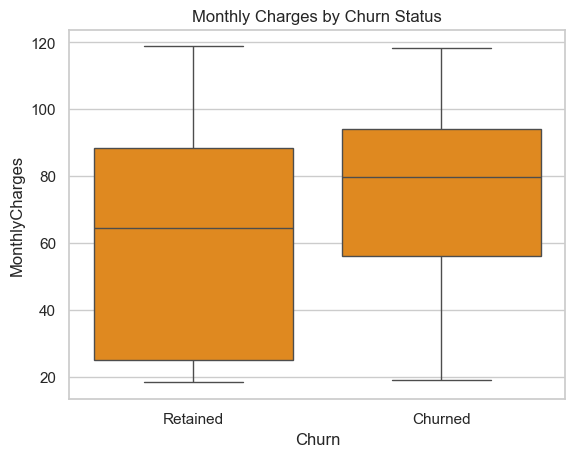

In [ ]:
# Task 17 — numerical feature 2 vs Churn
print(df.groupby("Churn")["MonthlyCharges"].agg(["count", "mean", "median"]).round(2))
sns.boxplot(data=df, x="Churn", y="MonthlyCharges", color="darkorange")
plt.xticks([0, 1], ["Retained", "Churned"])
plt.title("Monthly Charges by Churn Status")
plt.show()

**Observation:** Churned customers have higher monthly charges on average than retained customers.
**Evidence:** Mean monthly charges are $74.44 for churned customers and $61.27 for retained customers.
**Possible Explanation:** Higher bills may increase price sensitivity, or they may proxy for service bundles and fiber customers that have higher observed churn.

---

## Part 8 — Correlation & Feature Relationships

Numerical features can be related to each other, not just to the target. Strongly correlated features can cause redundancy problems later, so it's worth knowing about them now.

*Concepts/functions you may find useful:* `df.corr(numeric_only=True)`, `sns.heatmap(corr_matrix, annot=True)`

**Tasks**
18. Compute and visualize the correlation matrix of the numerical features. Which pairs appear most correlated?
19. Does correlation imply causation here? Could any highly correlated features cause problems for a future model? Answer in 2–3 sentences.

                SeniorCitizen  tenure  MonthlyCharges  TotalCharges  Churn
SeniorCitizen           1.000   0.017           0.220         0.103  0.151
tenure                  0.017   1.000           0.248         0.825 -0.352
MonthlyCharges          0.220   0.248           1.000         0.651  0.193
TotalCharges            0.103   0.825           0.651         1.000 -0.199
Churn                   0.151  -0.352           0.193        -0.199  1.000


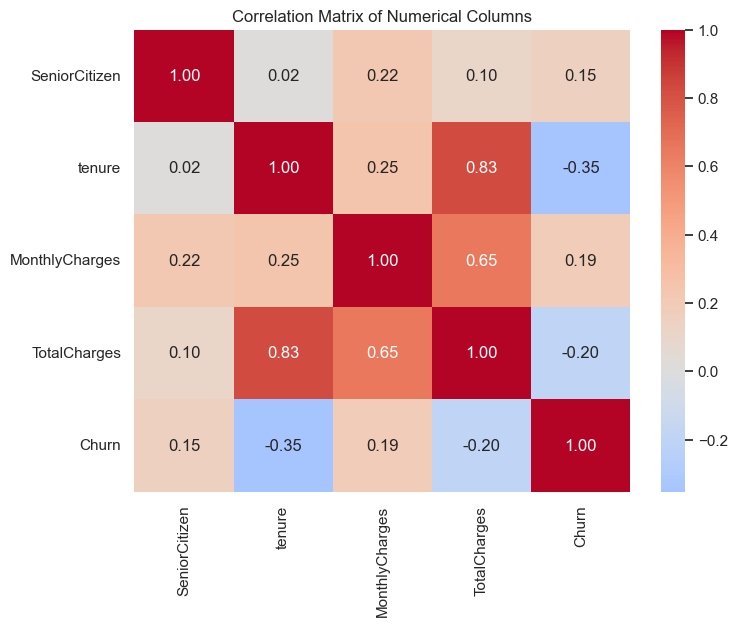

Strongest pairs:
tenure          TotalCharges    0.825
MonthlyCharges  TotalCharges    0.651
tenure          Churn          -0.352
dtype: float64


In [ ]:
# Task 18 — correlation matrix and heatmap
numeric_df = clean_intermediate_df.select_dtypes(include=np.number)
corr_matrix = numeric_df.corr()
print(corr_matrix.round(3))
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix of Numerical Columns")
plt.show()

pairs = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)).stack().sort_values(key=abs, ascending=False)
print("Strongest pairs:")
print(pairs.head(3).round(3))

**Answer 18 (most correlated pairs):**
The strongest relationship is between `tenure` and `TotalCharges` ($r \approx 0.83$), followed by `MonthlyCharges` and `TotalCharges` ($r \approx 0.65$), and `tenure` and `MonthlyCharges` ($r \approx 0.25$).

**Answer 19 (correlation vs. causation; potential problems):**
Correlation shows association, not proof that one variable causes another; for example, total charges naturally increase with both tenure and monthly charges. Highly correlated features can provide redundant information and make coefficients harder to interpret in some models, although tree-based models are generally less sensitive to this issue.

---

## Part 9 — Data Leakage Awareness

In Lab 3 you will train a classifier. Before that, you must check whether any column contains information that would not realistically be available at the moment of prediction — using such a column would make a model look artificially accurate.

**Tasks**
20. Inspect the columns for anything that looks like it could only be known after a customer has already churned, or that is purely an identifier. List any suspects and explain your reasoning.
21. In 2–3 sentences, explain what would go wrong if such a column were left in the model's input features.

**Answer 20 (suspect columns and reasoning):**
`customerID` is the main suspect because it is purely an identifier and has no business meaning as a customer behavior feature. No column explicitly records a post-churn event such as a cancellation date or retention intervention; `Churn` is the target and must not be included among model inputs.

**Answer 21 (what would go wrong):**
An identifier can encourage a model to memorize arbitrary record patterns that do not generalize to new customers. A post-outcome field would leak the answer into the inputs, producing unrealistically high validation performance and failing when predictions must be made before churn occurs.

---

## Part 10 — ML-Readiness Checklist

| Column | Type | Role | Action | Reason |
|---|---|---|---|---|
| customerID | Identifier | Identifier | Remove | Arbitrary record identifier; risks memorization. |
| gender | Categorical | Feature | Keep | Demographic feature; inspect for fairness during modeling. |
| SeniorCitizen | Binary numerical | Feature | Keep | Indicates age-group membership; check fairness and encoding. |
| Partner | Categorical | Feature | Keep | Household relationship may relate to retention. |
| Dependents | Categorical | Feature | Keep | Household responsibilities may relate to retention. |
| tenure | Numerical | Feature | Keep | Strong relationship with churn; already numeric. |
| PhoneService | Categorical | Feature | Keep | Service possession may distinguish customer segments. |
| MultipleLines | Categorical | Feature | Keep | Describes phone-service configuration. |
| InternetService | Categorical | Feature | Keep | Service type has different observed churn rates. |
| OnlineSecurity | Categorical | Feature | Keep | Add-on service may relate to satisfaction and retention. |
| OnlineBackup | Categorical | Feature | Keep | Add-on service may capture customer engagement. |
| DeviceProtection | Categorical | Feature | Keep | Service bundle feature that may relate to retention. |
| TechSupport | Categorical | Feature | Keep | Support access may influence customer experience. |
| StreamingTV | Categorical | Feature | Keep | Captures entertainment-service preferences. |
| StreamingMovies | Categorical | Feature | Keep | Captures entertainment-service preferences. |
| Contract | Categorical | Feature | Keep | Strongest practical segmentation signal observed. |
| PaperlessBilling | Categorical | Feature | Keep | Billing preference may proxy for customer behavior. |
| PaymentMethod | Categorical | Feature | Keep | Payment method shows meaningful segment differences. |
| MonthlyCharges | Numerical | Feature | Keep | Numeric pricing feature; inspect scale and skew. |
| TotalCharges | Numerical | Feature | Impute then keep | Convert/verify numeric values and fill 11 missing values with the median. |
| Churn | Binary numerical | Target | Keep separately | Outcome to predict; never include as an input feature. |

---

## Part 11 — Building the Clean Dataset

Bring together every cleaning decision into one final dataframe, `clean_df`, that Lab 3 can load directly.

> Do **not** split into train/test, encode categorical variables, or train any model — that happens in Lab 3.

**Tasks**
23. Produce `clean_df` with correct data types, missing values handled, duplicates handled, and irrelevant identifier columns removed where justified. Save it (e.g. `clean_churn.csv`) alongside your notebook.
24. Print `df.info()` (or equivalent) for `clean_df` as final proof that every issue identified earlier has been resolved.

In [ ]:
# Task 23 — assemble clean_df from your cleaning decisions
clean_df = clean_intermediate_df.drop(columns=["customerID"]).copy()
clean_df = clean_df.drop_duplicates()
clean_df["TotalCharges"] = clean_df["TotalCharges"].astype("float64")
clean_df["Churn"] = clean_df["Churn"].astype("int8")

# Save the cleaned dataset alongside this notebook
clean_df.to_csv("clean_churn.csv", index=False)
print(f"Saved clean_churn.csv with shape {clean_df.shape}")
clean_df.head()

Saved clean_churn.csv with shape (7021, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [ ]:
# Task 24 — final proof: info() / isnull().sum() / duplicated().sum() on clean_df
clean_df.info()
print("Total missing values:", int(clean_df.isna().sum().sum()))
print("Duplicate rows:", int(clean_df.duplicated().sum()))
print("Churn distribution:")
print(clean_df["Churn"].value_counts().sort_index())

<class 'pandas.DataFrame'>
Index: 7021 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7021 non-null   str    
 1   SeniorCitizen     7021 non-null   int64  
 2   Partner           7021 non-null   str    
 3   Dependents        7021 non-null   str    
 4   tenure            7021 non-null   int64  
 5   PhoneService      7021 non-null   str    
 6   MultipleLines     7021 non-null   str    
 7   InternetService   7021 non-null   str    
 8   OnlineSecurity    7021 non-null   str    
 9   OnlineBackup      7021 non-null   str    
 10  DeviceProtection  7021 non-null   str    
 11  TechSupport       7021 non-null   str    
 12  StreamingTV       7021 non-null   str    
 13  StreamingMovies   7021 non-null   str    
 14  Contract          7021 non-null   str    
 15  PaperlessBilling  7021 non-null   str    
 16  PaymentMethod     7021 non-null   str    
 17  MonthlyChar

---

## Part 12 — Key Findings & Final Reflection

**Task 25 — Five Important Findings**

**Finding 1**
- Observation: Churn is a minority but substantial outcome.
- Evidence: 1,869 of 7,043 customers churned (26.54%).
- Interpretation: A future classifier must distinguish churn well rather than rely on majority-class accuracy.

**Finding 2**
- Observation: Contract type is strongly associated with churn.
- Evidence: Churn is 42.71% for month-to-month customers, compared with 2.83% for two-year customers.
- Interpretation: Contract commitment is a high-value retention segmentation variable.

**Finding 3**
- Observation: Churned customers have much shorter tenure.
- Evidence: Mean tenure is 17.98 months for churned customers versus 37.57 months for retained customers.
- Interpretation: Early customer lifecycle support may be especially important.

**Finding 4**
- Observation: Fiber optic customers show higher churn than other internet-service groups.
- Evidence: Fiber churn is 41.89%, compared with 18.96% for DSL and 7.40% for no internet service.
- Interpretation: Service type may capture price, quality, or segment differences that deserve further investigation.

**Finding 5**
- Observation: Total charges are strongly related to tenure.
- Evidence: The correlation is approximately 0.83.
- Interpretation: Both features are useful but partly redundant because total charges accumulate over time.

---

**Task 26 — Final Reflection Questions**

1. What was the most important data-quality issue you found?
   The 11 missing `TotalCharges` values were the main issue because the feature is numeric and relevant to analysis. I imputed them with the median after confirming the missing proportion was only 0.16%.
2. What was the most interesting pattern you discovered?
   Month-to-month contracts had dramatically higher churn than one-year and two-year contracts, suggesting that commitment level is closely associated with retention.
3. Which feature seems most useful for predicting churn?
   `Contract` appears most useful from the observed group differences, with `tenure` also showing a strong relationship.
4. Which feature should probably not be used, and why?
   `customerID` should be removed because it is an arbitrary identifier rather than a behavioral feature.
5. What preprocessing will be required before ML modeling (conceptually — do not implement it)?
   Split features from `Churn`, encode categorical variables, scale numerical variables when required by the model, and fit all preprocessing using training data only.
6. What would you do next if you had another 3 hours?
   I would validate the patterns with subgroup counts, investigate fiber-optic and payment-method interactions, build a leakage-safe preprocessing pipeline, and compare models using precision, recall, F1, ROC-AUC, and a confusion matrix.

---

## Bonus Tasks (Optional)

- Create one additional meaningful visualization not required above.
- Investigate a surprising customer subgroup you didn't expect to find.
- Calculate churn rate across a combination of 2+ customer segments at once.
- Identify one possible feature-engineering opportunity for Lab 3.
- Identify one possible source of bias in this dataset.

InternetService    DSL  Fiber optic     No
Contract                                  
Month-to-month   32.22        54.61  18.89
One year          9.30        19.29   2.47
Two year          1.91         7.23   0.78


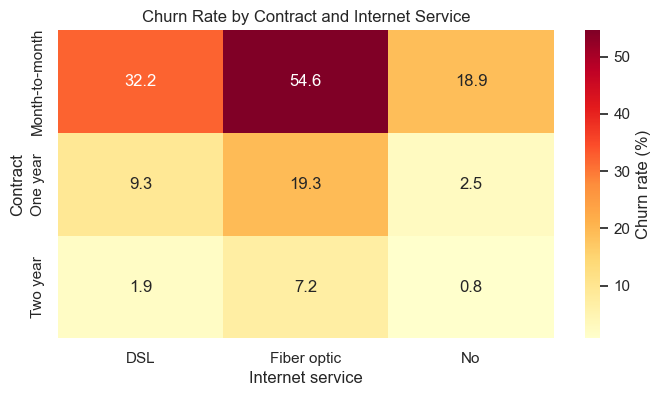

In [ ]:
# Bonus — churn rate across contract and internet-service segments
segment_churn = pd.pivot_table(
    df,
    values="Churn",
    index="Contract",
    columns="InternetService",
    aggfunc="mean"
) * 100
print(segment_churn.round(2))
plt.figure(figsize=(8, 4))
sns.heatmap(segment_churn, annot=True, fmt=".1f", cmap="YlOrRd", cbar_kws={"label": "Churn rate (%)"})
plt.title("Churn Rate by Contract and Internet Service")
plt.ylabel("Contract")
plt.xlabel("Internet service")
plt.show()

---

## Submission Checklist

Before submitting, confirm you have:

- [ ] Completed all 26 tasks above, with written interpretation for every chart and decision
- [ ] A working `clean_df`, saved as `clean_churn.csv`
- [ ] A completed ML-readiness table (Part 10) covering every column
- [ ] Five Key Findings written (Part 12)
- [ ] Answered all six Final Reflection questions
- [ ] Committed and pushed this notebook + `clean_churn.csv` to your GitHub repository
- [ ] Added your GitHub repository link at the top of this notebook